## Diffeomorphic Bases Square

Here, we will experiment with the idea of transforming bases using the half-density idea and normalizing flows. First off, get the imports out of the way!

In [ ]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

In [2]:
%autoreload 2
from half_densities.diffeomorphisms.normalizing_flows import build_unitcube_diffeo

d = 2
T = build_unitcube_diffeo(d, hidden_features=2, num_layers=2, num_blocks=2, eps=1e-7)
T = T.to(device)
# Sample some points in (0,1)^d
x = torch.rand(8, d).to(device)
# Forward map and determinant of Jacobian
y, detJ = T(x, context=None)
print("y in (0,1)^d:", y.min().item(), y.max().item())
print("det J_T(x):", detJ)

# Inverse consistency check
x_rec, detJ_inv = T.inverse(y, context=None)
print("max |x - T^{-1}(T(x))|:", (x - x_rec).abs().max().item())
# Sanity: det(T) * det(T^{-1}) = 1 (up to numerical error)
print("max |detJ * detJ_inv - 1|:", (torch.exp(detJ + detJ_inv) - 1).abs().max().item())

y in (0,1)^d: 0.1624383725600511 0.8307044716329153
det J_T(x): tensor([-1.8293, -1.1113, -1.8311, -0.3340,  1.1974, -0.3970, -0.0980, -0.8710],
       device='cuda:0', grad_fn=<AddBackward0>)
max |x - T^{-1}(T(x))|: 7.771561172376096e-16
max |detJ * detJ_inv - 1|: 8.881784197001252e-15


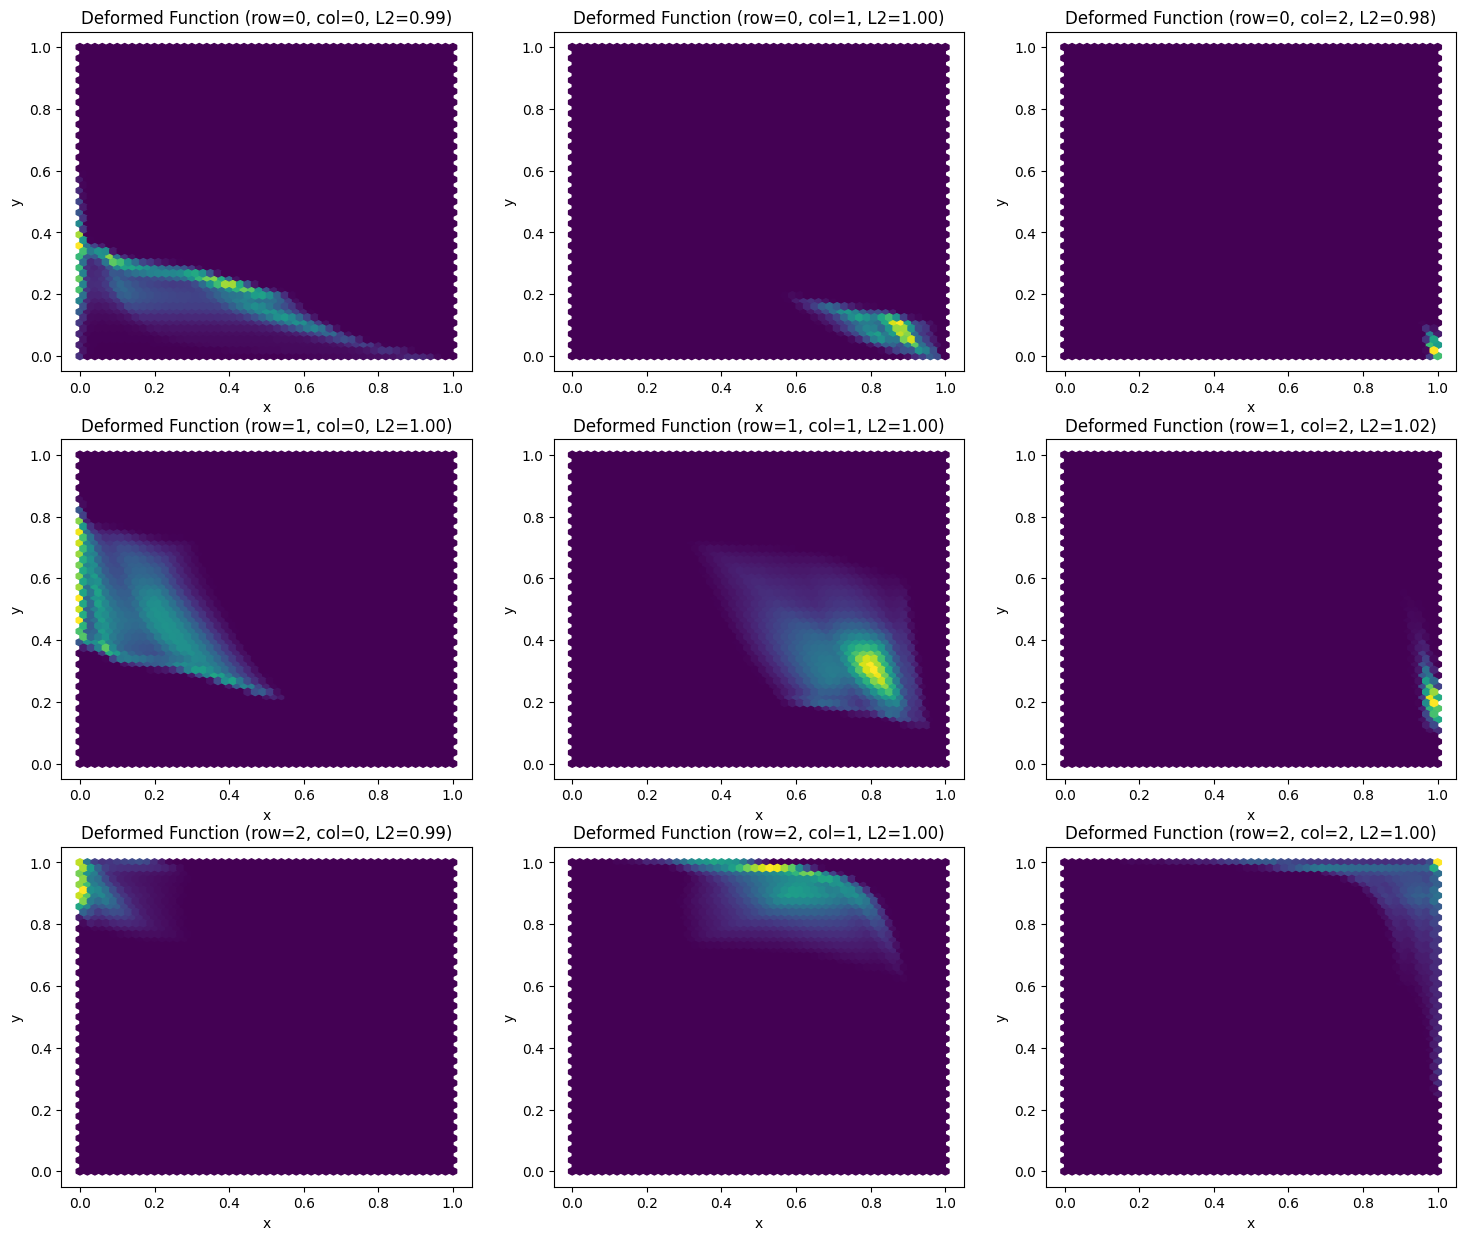

In [3]:
%autoreload 2
from half_densities.utils import tent_basis_2d, fourier_basis_2d

def deformed_basis(xy, transform, basis_fn, **kwargs):
    transformed_xy, logabsdet = transform(xy, context=None)
    basis_fn_vals = basis_fn(transformed_xy, **kwargs)
    return basis_fn_vals * torch.exp(0.5 * logabsdet)

# visualize bumps
all_original_vals_tent = []
all_deformed_vals_tent = []
all_original_vals_fourier = []
all_deformed_vals_fourier = []

fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
N = 100000_0
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        xy = torch.rand(N, 2).to(device)
        original_vals_tent = tent_basis_2d(xy, row=row, col=col, total_rows=3, total_cols=3).detach().cpu().numpy()
        deformed_vals_tent = deformed_basis(xy, transform=T, basis_fn=tent_basis_2d, row=row, col=col, total_rows=3, total_cols=3).detach().cpu().numpy()
        all_original_vals_tent.append(original_vals_tent)
        all_deformed_vals_tent.append(deformed_vals_tent)
        original_vals_fourier = fourier_basis_2d(xy, kx=row + 1, ky=col + 1).detach().cpu().numpy()
        deformed_vals_fourier = deformed_basis(xy, transform=T, basis_fn=fourier_basis_2d, kx=row + 1, ky=col + 1).detach().cpu().numpy()
        all_original_vals_fourier.append(original_vals_fourier)
        all_deformed_vals_fourier.append(deformed_vals_fourier)
        # approximate integral by monte carlo
        integr = np.sqrt((deformed_vals_tent * deformed_vals_tent).mean()).item()  # should be close to zero
        ax.hexbin(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), C=deformed_vals_tent, gridsize=50, cmap='viridis') 
        ax.set_title(f'Deformed Function (row={row}, col={col}, L2={integr:.2f})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    

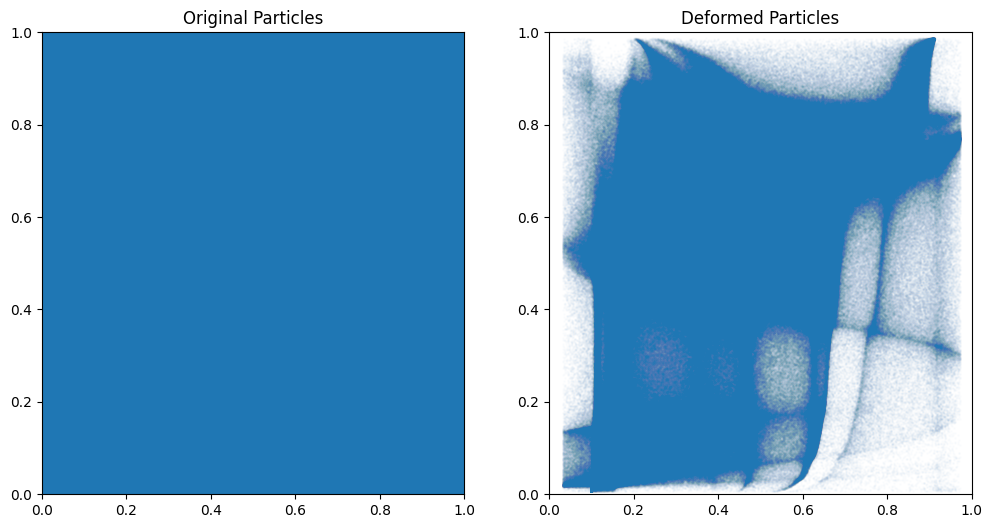

In [4]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
xy = torch.rand(N * 10, 2).to(device)
ax[0].scatter(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), s=1, alpha=0.01)
ax[0].set_xlim(0,1)
ax[0].set_ylim(0,1)
ax[0].set_title('Original Particles')
transformed_xy, logabsdet = T(xy, context=None)
ax[1].scatter(transformed_xy[:,0].detach().cpu(), transformed_xy[:,1].detach().cpu(), s=1, alpha=0.01)
ax[1].set_xlim(0,1)
ax[1].set_ylim(0,1)
ax[1].set_title('Deformed Particles')
plt.show()

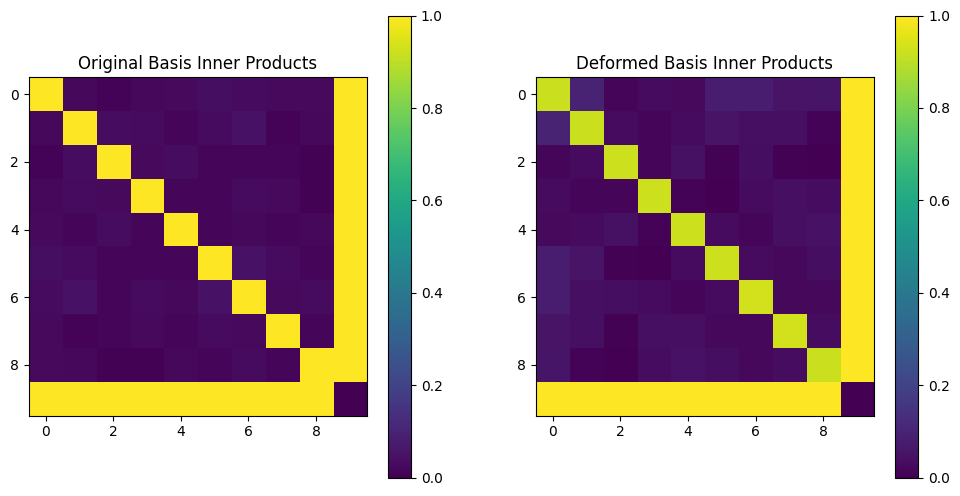

In [5]:
all_original_vals = all_original_vals_fourier
all_deformed_vals = all_deformed_vals_fourier
inner_products_defomed = np.zeros((9, 9))
inner_products_original = np.zeros((9, 9))
for i in range(len(all_deformed_vals)):
    for j in range(len(all_deformed_vals)):
        inner_products_defomed[i, j] = np.sqrt(np.abs((all_deformed_vals[i] * all_deformed_vals[j]).mean()))
        inner_products_original[i, j] = np.sqrt(np.abs((all_original_vals[i] * all_original_vals[j]).mean()))

# add a row with all zeros and a column with all ones
inner_products_original = np.pad(inner_products_original, ((0,1),(0,1)), mode='constant', constant_values=0)
inner_products_defomed = np.pad(inner_products_defomed, ((0,1),(0,1)), mode='constant', constant_values=0)
inner_products_original[-1, :-1] = 1.0
inner_products_original[:-1, -1] = 1.0
inner_products_defomed[-1, :-1] = 1.0
inner_products_defomed[:-1, -1] = 1.0

# plot two heatmaps side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
im0 = axes[0].imshow(inner_products_original, cmap='viridis')
axes[0].set_title('Original Basis Inner Products')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(inner_products_defomed, cmap='viridis')
axes[1].set_title('Deformed Basis Inner Products')
# set the minimum of the colorbar to 0
fig.colorbar(im1, ax=axes[1])
plt.show()

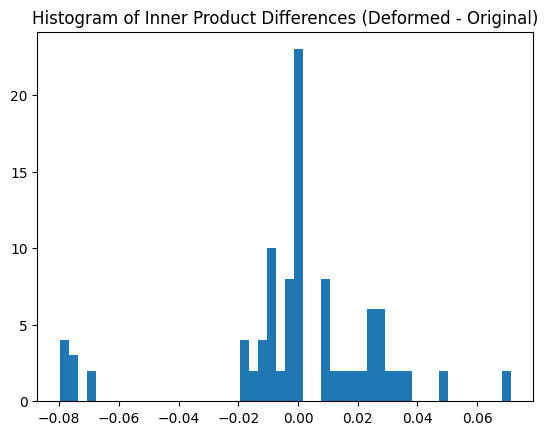

In [6]:
plt.hist(inner_products_defomed.flatten() - inner_products_original.flatten(), bins=50)
plt.title('Histogram of Inner Product Differences (Deformed - Original)')
plt.show()

## Continuous Time Basis

Visualize the vector field:



/home/hamid/miniconda3/envs/projections/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


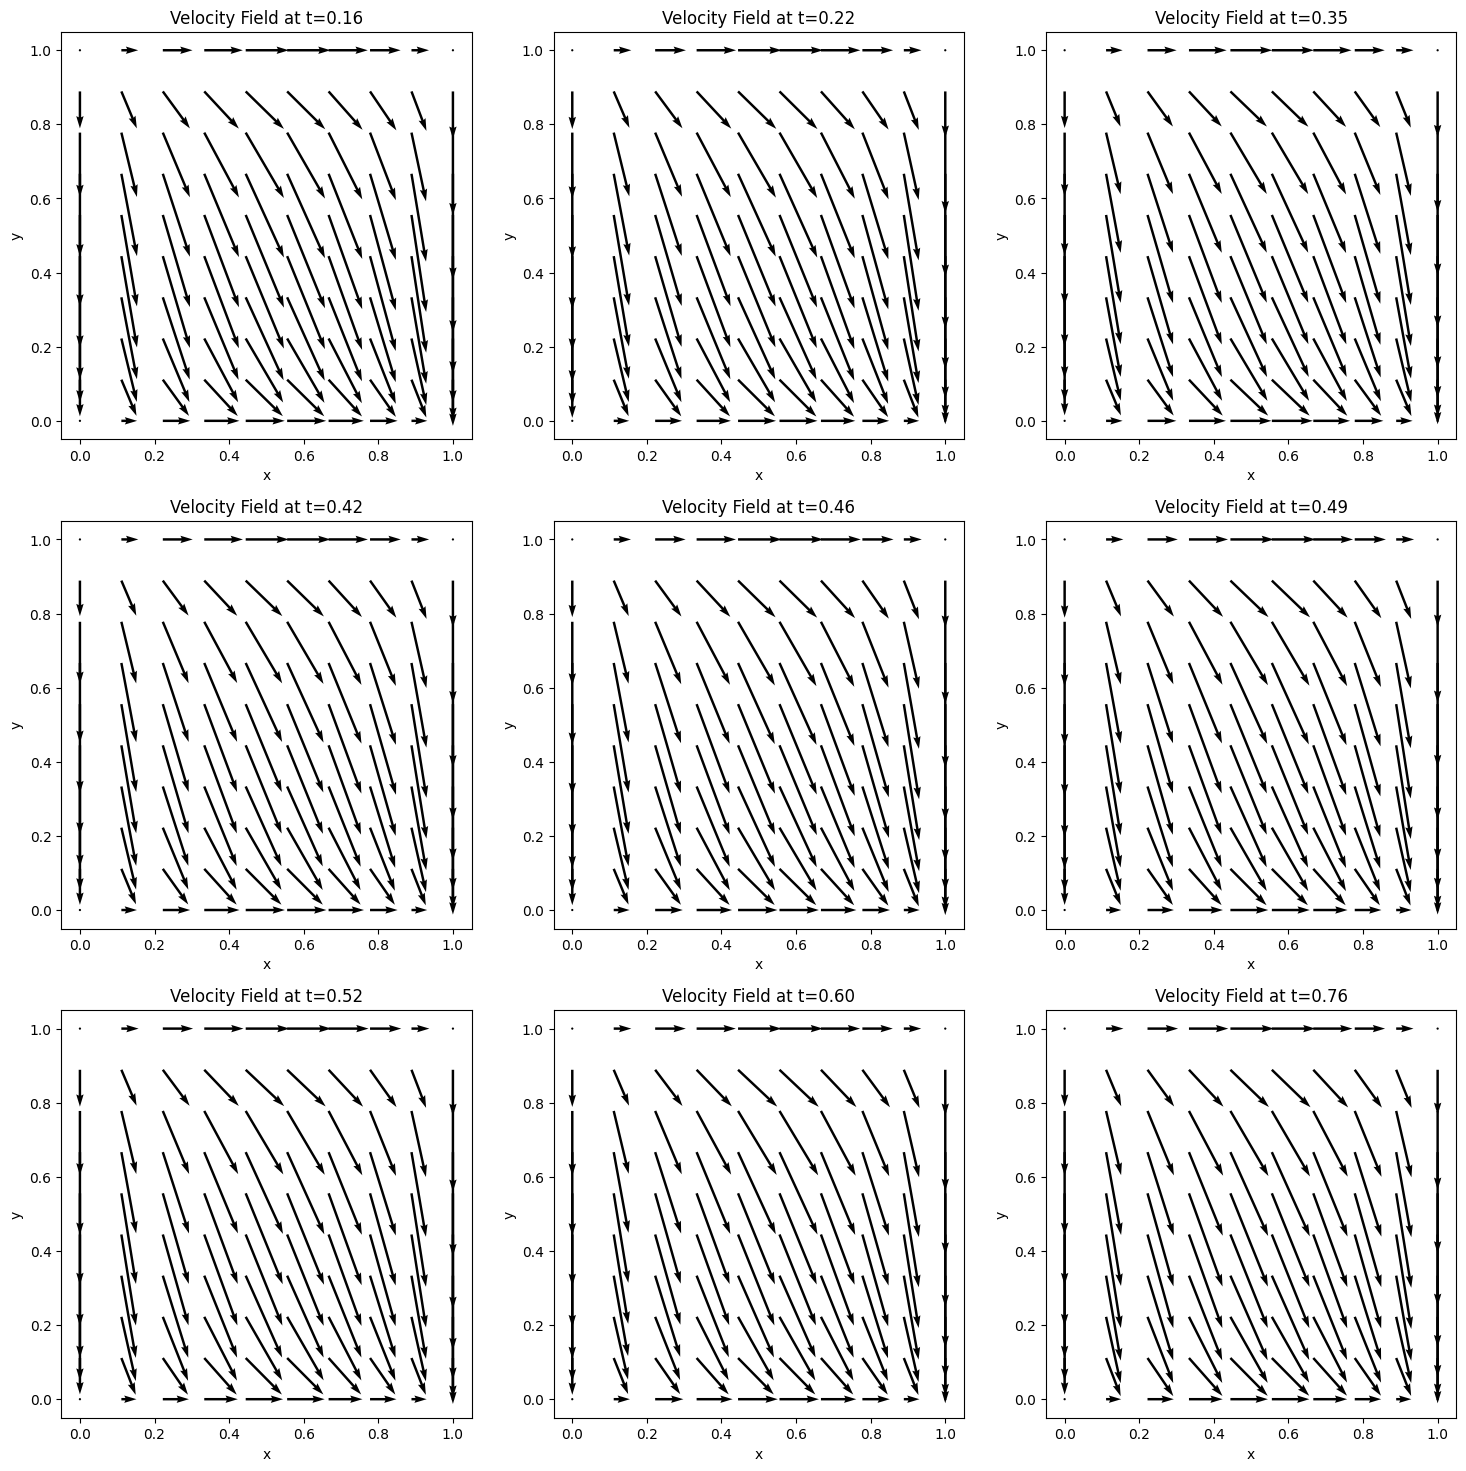

In [8]:
%autoreload 2
from half_densities.diffeomorphisms.continuous_time import CTCubeFlow

torch.manual_seed(0)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
N = 10 * 10
T = CTCubeFlow(
    dimensions= 2,
    gamma = 1.,
).to(device)
viz_magnitude = 100.0
# create a meshgrid of points in (0,1)^2
xy = torch.linspace(0, 1, int(math.sqrt(N)))
xy = torch.stack(torch.meshgrid(xy, xy), -1).reshape(-1, 2).to(device)
xy = xy.unsqueeze(0).repeat(9, 1, 1).reshape(-1, 2)
# sample 9 random times in [0,1]
t = torch.rand(9).to(device)
# sort t for better visualization
t, _ = torch.sort(t)
# repeat t for each point
t = torch.repeat_interleave(t, N)
v =  viz_magnitude * T.velocity_field(t, xy)
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = row * 3 + col
        ax.quiver(xy[idx * N:(idx + 1) * N,0].detach().cpu(), xy[idx * N:(idx + 1) * N,1].detach().cpu(),
                  v[idx * N:(idx + 1) * N,0].detach().cpu(), v[idx * N:(idx + 1) * N,1].detach().cpu(),
                  angles='xy', scale_units='xy', scale=10.0, alpha=1)
        ax.set_title(f'Velocity Field at t={t[idx * N].item():.2f}')
        ax.set_xlim(-.05,1.05)
        ax.set_ylim(-.05,1.05)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

Apply the pullback operator:

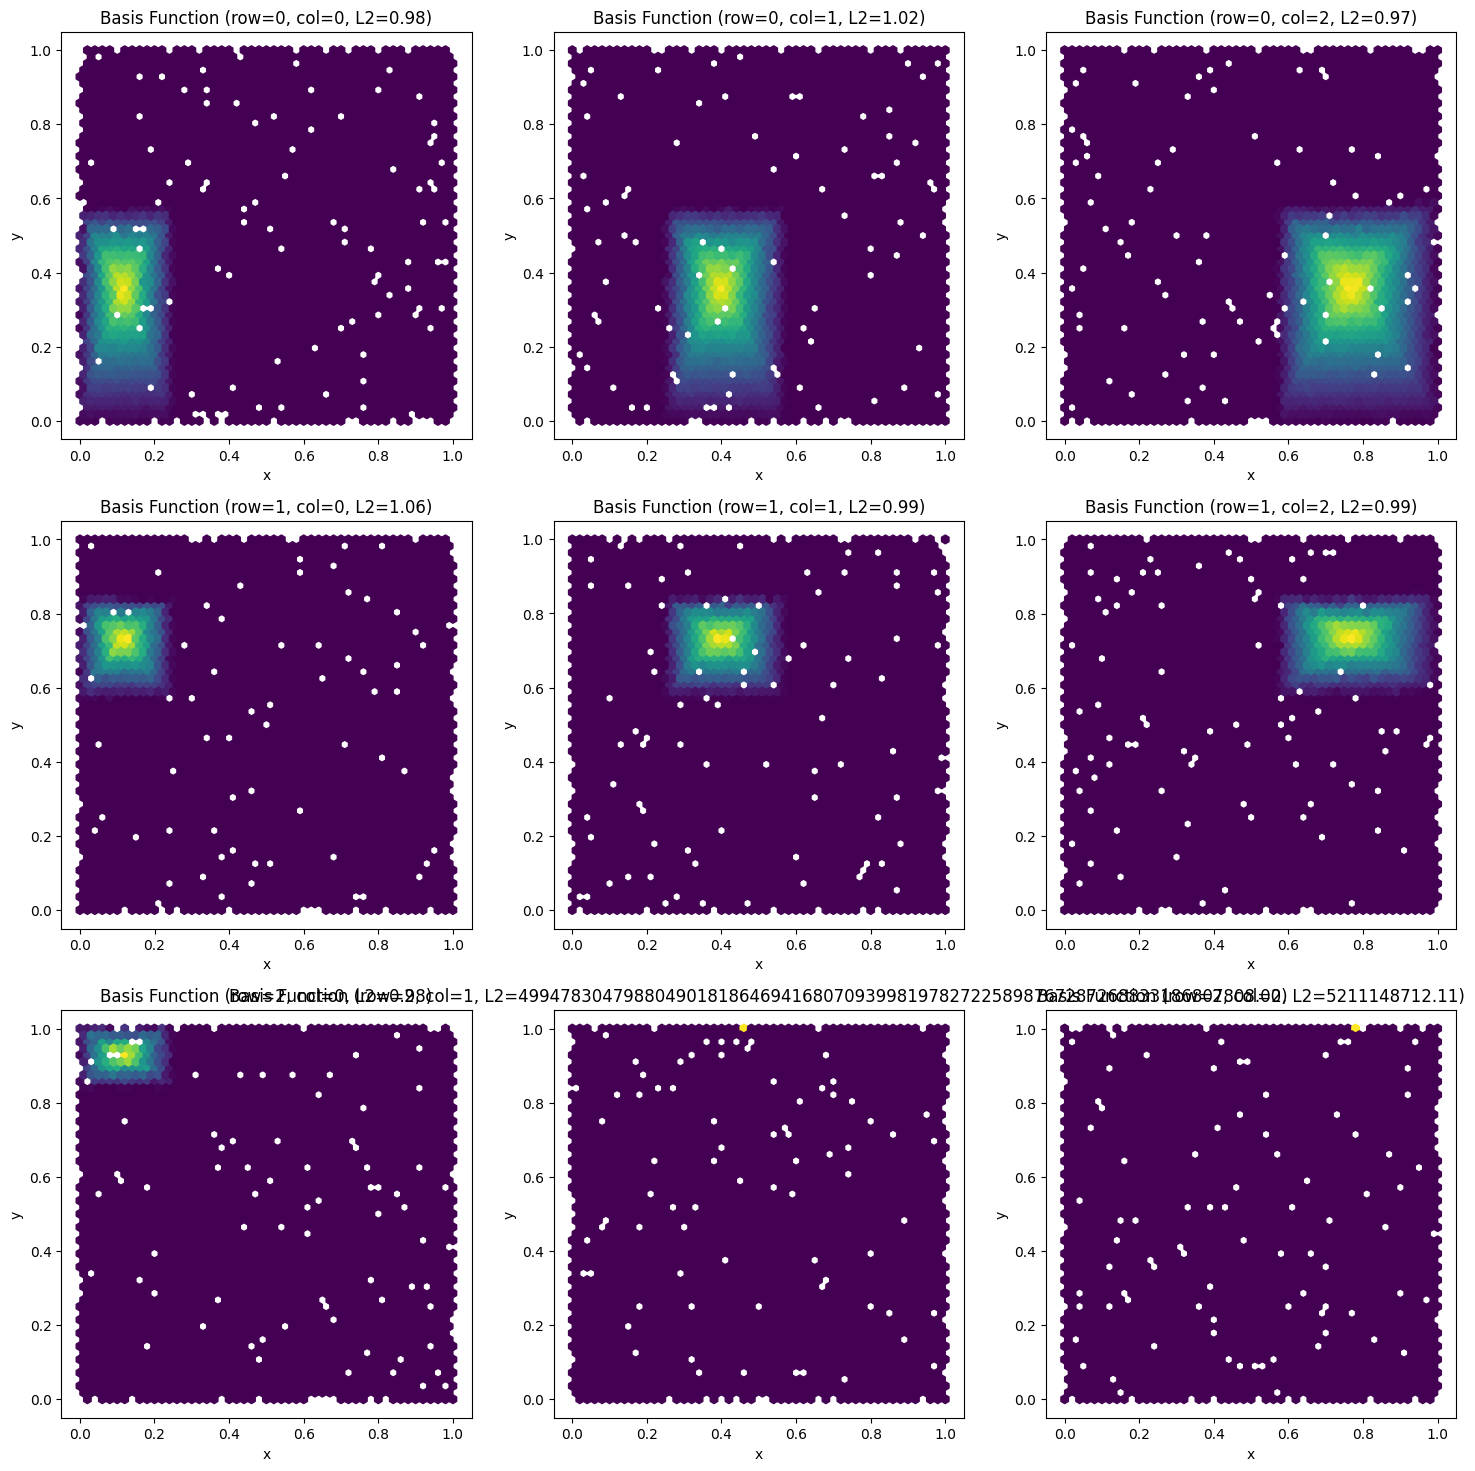

In [9]:
%autoreload 2
from half_densities.diffeomorphisms.continuous_time import CTCubeFlow

from half_densities.utils import tent_basis_2d
import functools

# seed everything for reproducibility
torch.manual_seed(0)
N = 1000
end_time = 10.0
xy = torch.rand(9  * N, 2).to(device)
all_deformed_vals = []
all_original_vals = []
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        basis_func = functools.partial(tent_basis_2d, total_rows=3, total_cols=3, row=row, col=col)
        N = 1000_0
        xy = torch.rand(N, 2).to(device)
        all_original_vals.append(
            basis_func(torch.rand(N, 2).to(device)).detach().cpu().numpy()
        )
        deformed_vals = T.evaluate(
            xy,
            start_time=0.0,
            end_time=end_time,
            initial_basis_fn=basis_func,
            n_steps=1000,
        )
        all_deformed_vals.append(deformed_vals.detach().cpu().numpy())
        # approximate integral by monte carlo
        integr = torch.sqrt((deformed_vals * deformed_vals).mean()).item()  # should be close to zero
        ax.hexbin(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), C=deformed_vals.detach().cpu(), gridsize=50, cmap='viridis') 
        ax.set_title(f'Basis Function (row={row}, col={col}, L2={integr:.2f})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

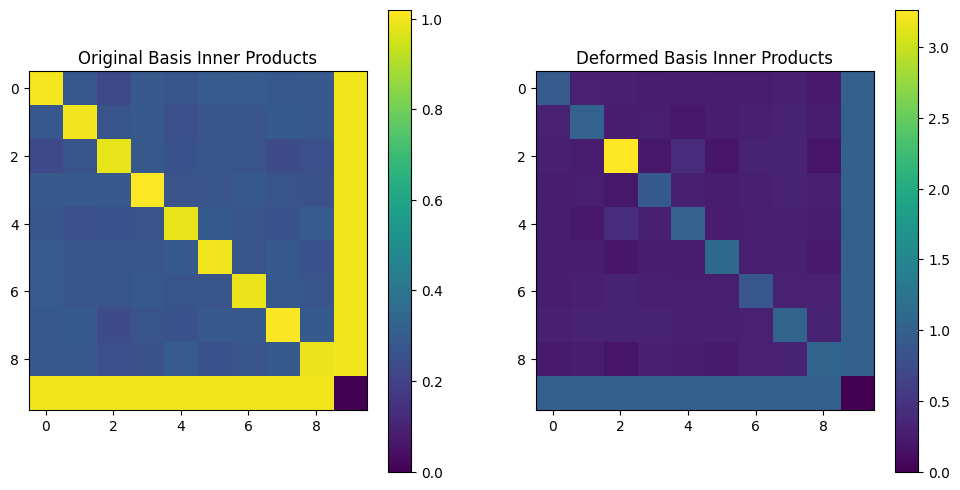

In [4]:
inner_products_defomed = np.zeros((9, 9))
inner_products_original = np.zeros((9, 9))
for i in range(len(all_deformed_vals)):
    for j in range(len(all_deformed_vals)):
        inner_products_defomed[i, j] = np.sqrt((all_deformed_vals[i] * all_deformed_vals[j]).mean())
        inner_products_original[i, j] = np.sqrt((all_original_vals[i] * all_original_vals[j]).mean())

# add a row with all zeros and a column with all ones
inner_products_original = np.pad(inner_products_original, ((0,1),(0,1)), mode='constant', constant_values=0)
inner_products_defomed = np.pad(inner_products_defomed, ((0,1),(0,1)), mode='constant', constant_values=0)
inner_products_original[-1, :-1] = 1.0
inner_products_original[:-1, -1] = 1.0
inner_products_defomed[-1, :-1] = 1.0
inner_products_defomed[:-1, -1] = 1.0

# plot two heatmaps side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
im0 = axes[0].imshow(inner_products_original, cmap='viridis')
axes[0].set_title('Original Basis Inner Products')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(inner_products_defomed, cmap='viridis')
axes[1].set_title('Deformed Basis Inner Products')
# set the minimum of the colorbar to 0
fig.colorbar(im1, ax=axes[1])
plt.show()

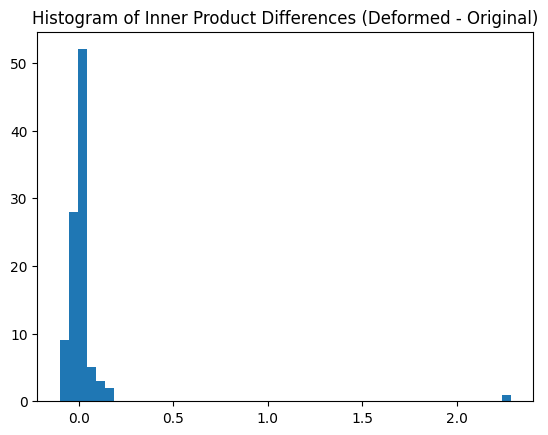

In [5]:
plt.hist(inner_products_defomed.flatten() - inner_products_original.flatten(), bins=50)
plt.title('Histogram of Inner Product Differences (Deformed - Original)')
plt.show()

## Training Loop

Now let us train $T$ to match the representation.

In [ ]:
from half_densities.utils import random_bandpass_field
from tqdm import tqdm

N = 500
T = build_unitcube_diffeo(d, hidden_features=16, num_layers=4, num_blocks=2, eps=1e-7)
T = T.to(device)
optimizer = torch.optim.Adam(T.parameters(), lr=1e-3)
epochs = 1000
freq_viz = 1000_0
smoothed_loss = None
loss_history = []
pbar = tqdm(range(epochs))
for idx in pbar:
    xy = torch.rand(N, 2).to(device)
    vals = random_bandpass_field(xy, seed=idx, f_lo=0., f_hi=10.0, n_waves=256)  # shape (N,)
    integr = torch.sqrt((vals * vals).mean()).item()  # estimate the l2 for normalization
    
    # now iterate over all of the deformed basis functions and maximize their squared inner products with vals
    optimizer.zero_grad()
    loss = 0.0
    for row in range(3):
        for col in range(3):
            deformed_vals = deformed_basis(xy, transform=T, basis_fn=fourier_basis_2d, kx=row + 1, ky=col + 1)
            loss -= (torch.mean((vals / integr) * deformed_vals)) ** 2
    loss.backward()
    smoothed_loss = loss.item() if smoothed_loss is None else 0.9 * smoothed_loss + 0.1 * loss.item()
    pbar.set_postfix({'loss': smoothed_loss})
    optimizer.step()
    loss_history.append(loss.item())
    if (idx + 1) % freq_viz == 0:
        fig, axes = plt.subplots(figsize=(6 * 3,5 * 3), nrows=3, ncols=3)
        for row in range(3):
            for col in range(3):
                ax = axes[row, col]
                xy = torch.rand(N, 2).to(device)
                vals = deformed_basis(xy, transform=T, basis_fn=fourier_basis_2d, kx=row + 1, ky=col + 1).detach()
                ax.hexbin(xy.detach().cpu()[:,0], xy.detach().cpu()[:,1], C=vals.detach().cpu(), gridsize=50, cmap='viridis') 
                ax.set_title(f'Deformed Function (row={row}, col={col})')
                ax.set_xlabel('x')
                ax.set_ylabel('y')
        plt.show()
    

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [02:13<00:00,  7.49it/s, loss=-0.197]


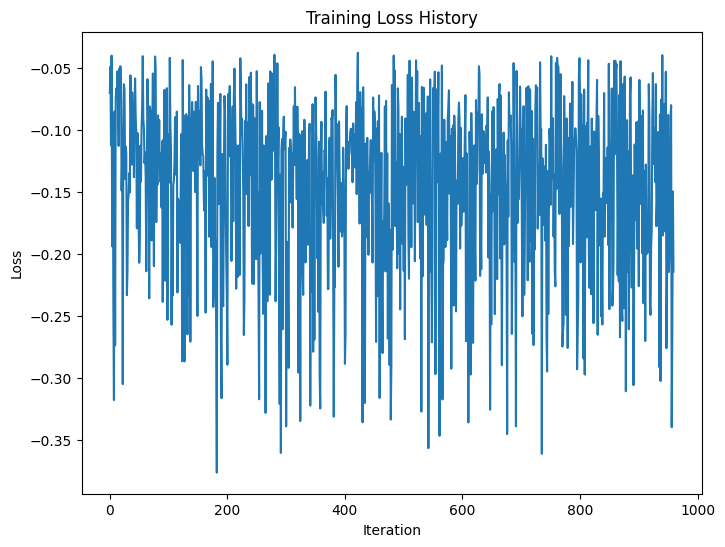

In [ ]:
# plot the loss history
fig, ax = plt.subplots(figsize=(8,6))
# remove outliers for better visualization
# loss_history = np.array(loss_history)
# q_low = np.percentile(loss_history, 1)
# q_high = np.percentile(loss_history, 99)
# loss_history = loss_history[(loss_history > q_low) & (loss_history < q_high)]
ax.plot(loss_history)
# ax.set_yscale('log')
ax.set_xlabel('Iteration')  
ax.set_ylabel('Loss')
ax.set_title('Training Loss History')
plt.show()